In [9]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from ase.build.surface import mx2
from ase.io import read,write
from mace.calculators import MACECalculator
from ase.optimize import BFGS
import sys
import os

# Add the directory to sys.path
sys.path.append(os.path.abspath("../relaxations"))
from utils import *

calc = MACECalculator(model_paths="../training/MoWSSe_bi_radius_8_reduced_all_1_swa_800_run-123_swa.model", 
                      device="cuda", default_dtype="float64")

def get_tmdc_bilayer(tmdc1,tmdc2,N,offset,d,parallel):
    
    a = {}
    a['WS2'] = 3.190902132
    a['MoS2'] = 3.186305534
    a['WSe2'] = 3.322874304
    a['MoSe2'] = 3.322339468

    t = {}
    t['WS2'] = 3.1570497014
    t['MoS2'] = 3.140170013
    t['WSe2'] = 3.367178811
    t['MoSe2'] = 3.3492559072
    
    ## Make tmdc monolayers and align them with the axes
    sup_tmdc1 = mx2(tmdc1,kind='2H',a=a[tmdc1],thickness=t[tmdc1],vacuum=8,size=(N,N,1))
    sup_tmdc1.rotate(60,[0,0,1],rotate_cell=True)
    sup_tmdc2 = mx2(tmdc2,kind='2H',a=a[tmdc2],thickness=t[tmdc2],vacuum=8,size=(N,N,1))
    sup_tmdc2.rotate(60,[0,0,1],rotate_cell=True)
    
    #Rotate 180 degrees to get XX' antiparallel stacking
    if not parallel:
        
        sup_tmdc2.rotate(180,sup_tmdc2.positions[1]-sup_tmdc2.positions[2],
                        center=(sup_tmdc2.positions[1]+sup_tmdc2.positions[2])/2)
        
    #Get unit lattice vectors
    #v1,v2,v3 = prim_tmdc2.get_cell()
    unit_v1 = np.array([1,0,0])
    unit_v2 = np.array([0,1,0])
    unit_v3 = np.array([0,0,1])
    
    #Get translation vector from offset and interlayer distance d
    translate_v1 = a[tmdc2]*offset[0]*unit_v1
    translate_v2 = a[tmdc2]*offset[1]*unit_v2
    translate_v3  = (d)*unit_v3
    
    sup_tmdc2.translate(translate_v1+translate_v2+translate_v3)
    
    bilayer = sup_tmdc1 + sup_tmdc2
    
    return bilayer

def passlog():
    pass

#Function to read lammps file for getting total energy
def read_lammps_energy(filename):

    file = open(filename)
    lines = list(reversed(file.readlines()))
    for i,line in enumerate(lines):
        if 'Energy initial, next-to-last, final =' in line:
            energy_line = lines[i-1]
            break
    final_energy = float(energy_line.split()[-1])
    return final_energy

# Function to get domain wall length
def curve_length(xdata, ydata):
    # Ensure inputs are numpy arrays
    xdata = np.array(xdata)
    ydata = np.array(ydata)
    
    # Calculate the differences between consecutive points
    dx = np.diff(xdata)
    dy = np.diff(ydata)
    
    # Calculate the Euclidean distance between consecutive points
    distances = np.sqrt(dx**2 + dy**2)
    
    # Sum up the distances to get the total length of the curve
    total_length = np.sum(distances)
    
    return total_length

Using head Default out of ['Default']


# Get low energy stacking energies

In [2]:
#Ones used in training
#Parallel stackings
# 1-> XX' 2-> 2 3-> MX' 4-> 4 5 -> XM' 6 -> f(d) 
P_offsets = np.array([[0,0],[0,1/(2*np.sqrt(3))],
            [0,-1/np.sqrt(3)],[0,1*np.sqrt(3)/2],
            [0,1/np.sqrt(3)],[-1/3,1/np.sqrt(3)]])

##Anti parallel stacking
# 1-> XX' 2-> 2 3-> 2H 4-> 4 5 -> MM' 6 -> f(d) 
AP_offsets = np.array([[0,0],[0,-1/(2*np.sqrt(3))],
            [0,-1/np.sqrt(3)],[0,1/(2*np.sqrt(3))],
            [0,1/np.sqrt(3)],[-1/3,0]])

energy_MX = {}
energy_XM = {}
energy_2H = {}
energy_MM = {}

for m1,m2 in [('Mo','Mo'),('W','W'),('Mo','W')]:
    for x1 in ['S','Se']:
               
        key = f'{m1}{x1}2/{m2}{x1}2' 
        
        print(f'Starting calculations for system {m1}{x1}2/{m2}{x1}2')
        atoms_MX = get_tmdc_bilayer(f'{m1}{x1}2',f'{m2}{x1}2',1,P_offsets[2],6.5,True)
        

        atoms_MX.calc = calc
        dyn = BFGS(atoms_MX)
        dyn.log = passlog
        dyn.run(fmax=0.00001)
        energy_MX[key] = atoms_MX.get_potential_energy()
        print(f"MX' : {energy_MX[key]}")

        atoms_XM = get_tmdc_bilayer(f'{m1}{x1}2',f'{m2}{x1}2',1,P_offsets[4],6.5,True)
        atoms_XM.calc = calc
        dyn = BFGS(atoms_XM)
        dyn.log = passlog
        dyn.run(fmax=0.00001)
        energy_XM[key] = atoms_XM.get_potential_energy()
        print(f"XM' : {energy_XM[key]}")
        
        atoms_2H = get_tmdc_bilayer(f'{m1}{x1}2',f'{m2}{x1}2',1,AP_offsets[2],6.5,False)
        atoms_2H.calc = calc
        dyn = BFGS(atoms_2H)
        dyn.log = passlog
        dyn.run(fmax=0.00001)
        energy_2H[key] = atoms_2H.get_potential_energy()      
        print(f'2H : {energy_2H[key]}')
        
        atoms_MM = get_tmdc_bilayer(f'{m1}{x1}2',f'{m2}{x1}2',1,AP_offsets[4],6.5,False)
        atoms_MM.calc = calc
        dyn = BFGS(atoms_MM)
        dyn.log = passlog
        dyn.run(fmax=0.00001)
        energy_MM[key] = atoms_MM.get_potential_energy()
        print(f"MM' : {energy_MM[key]}")

Starting calculations for system MoS2/MoS2


/software/easybuild/software/PyTorch/2.0-Miniconda3-4.12.0-Python-3.10.8/lib/python3.10/site-packages/torch/autograd/__init__.py:303: UserWarning: operator() profile_node %390 : int[] = prim::profile_ivalue(%dims.28)
 does not have profile information (Triggered internally at /opt/conda/conda-bld/pytorch_1682343967769/work/third_party/nvfuser/csrc/graph_fuser.cpp:104.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


MX' : -5122.576766324281
XM' : -5122.576766324281
2H : -5122.578961832597
MM' : -5122.568834432123
Starting calculations for system MoSe2/MoSe2
MX' : -6188.626859173368
XM' : -6188.626859173368
2H : -6188.635902279408
MM' : -6188.616730649079
Starting calculations for system WS2/WS2
MX' : -5665.602785928656
XM' : -5665.602785928656
2H : -5665.605452256545
MM' : -5665.594216121494
Starting calculations for system WSe2/WSe2
MX' : -6731.305516403895
XM' : -6731.305516403895
2H : -6731.313782995194
MM' : -6731.29681450571
Starting calculations for system MoS2/WS2
MX' : -5394.090006866428
XM' : -5394.089365055944
2H : -5394.092094896175
MM' : -5394.081945100415
Starting calculations for system MoSe2/WSe2
MX' : -6459.967107171113
XM' : -6459.966075182447
2H : -6459.9752582927695
MM' : -6459.957032694739


# Define domain wall energies

In [3]:
dwall_cost = {}
dwall_cost['P-MoS2/MoS2'] = 0.09266516706924521
dwall_cost['P-WS2/WS2'] = 0.09265909048599945
dwall_cost['P-MoSe2/MoSe2'] = 0.07415433930323345
dwall_cost['P-WSe2/WSe2'] = 0.07665743562200153

dwall_cost['AP-MoS2/MoS2'] = 0.08656171205244717
dwall_cost['AP-WS2/WS2'] = 0.08590237303938458
dwall_cost['AP-MoSe2/MoSe2'] = 0.07945729416051098
dwall_cost['AP-WSe2/WSe2'] = 0.08146105706109279

# Get node energies

In [4]:
# Results variability with grid size for AP cases
spacing_factors = np.linspace(0.07,0.2,10)

#iis = [10,11,12,14,15,20,30]
iis = [10,12,15,18,20,22,25,27,30]

node_energies_dict = {}

for stacking in ['P','AP']:
    for m1,m2 in [('Mo','Mo'),('W','W')]:
        for x1 in ['S','Se']:
            print(f'Starting calculations for {stacking}-{m1}{x1}2/{m2}{x1}2...')
        
            #Define array for storing node energy values
            if stacking=='P':
                node_energies = np.zeros(len(iis))
            else:
                node_energies = np.zeros((len(iis),len(spacing_factors)))

            
            for num_ii,ii in enumerate(iis):
                print(f'ii={ii}')
                
                # Get energy output file,
                outfile = f'output_files/{m1}{x1}2_{m2}{x1}2_{stacking}_{ii}.out'
                relaxed_energy = read_lammps_energy(outfile)
                xyzfile = f'../relaxations/relaxed_data/{m1}{x1}2_{m2}{x1}2_{stacking}_{ii}.xyz'
                atoms = read(xyzfile)
                nunitcells = len(atoms)//6

                if ii in [10,12]:
                    data = np.load(f'../relaxations/grid_data/{m1}{x1}2_{m2}{x1}2_{stacking}_{ii}_hres.npz')
                else:
                    data = np.load(f'../relaxations/grid_data/{m1}{x1}2_{m2}{x1}2_{stacking}_{ii}.npz')
                x_sc = data['x_sc']
                y_sc = data['y_sc']
                d_local_sc = data['d_local_sc']


                args_max_d = np.where(d_local_sc==max(d_local_sc))[0]  ##Get node indices
                xs_max_d = x_sc[args_max_d]
                ys_max_d = y_sc[args_max_d]
                
                # Get nodes and centroid for domain ratio and domain length calculations 
                i=50
                points = np.column_stack((xs_max_d,ys_max_d))
                distances = cdist(points,points)[i]
                nn1_dist = np.unique(np.round(distances,10))[1] ##Get first nearest neighbours of node
                nn1s = np.where(np.round(distances,10) == nn1_dist)[0]
                nn1_arg_1 = nn1s[np.where((xs_max_d[nn1s]<xs_max_d[i]) & (ys_max_d[nn1s]>ys_max_d[i]))[0][0]]
                nn1_arg_2 = nn1s[np.where((xs_max_d[nn1s]>xs_max_d[i]) & (ys_max_d[nn1s]>ys_max_d[i]))[0][0]]
                x_sol1,x_sol2,x_sol3 = xs_max_d[[i,nn1_arg_1,nn1_arg_2]]
                y_sol1,y_sol2,y_sol3 = ys_max_d[[i,nn1_arg_1,nn1_arg_2]]
                x_cent,y_cent = (x_sol1+x_sol2+x_sol3)/3,(y_sol1+y_sol2+y_sol3)/3
                 
                #Key to read dictionaries
                key = f'{m1}{x1}2/{m2}{x1}2'
    
                if stacking=='P':  ##P homobilayers
                    dwall_length = x_sol3-x_sol2
                    domain_ratio = 1
                    aligned_energy = nunitcells*(energy_MX[key]+domain_ratio*energy_XM[key])/(domain_ratio+1)
                    node_energy = relaxed_energy-aligned_energy-3*dwall_length*dwall_cost[f'{stacking}-{m1}{x1}2/{m2}{x1}2']
                    node_energies[num_ii] = node_energy
                    print(f'node_e={node_energy}  dlength={dwall_length} domainratio={domain_ratio}')
                else: #P heterobilayers and all AP
        
                    m = 0

                    for j,spacing_factor in enumerate(spacing_factors):
                    
                        spacing = int(nn1_dist/spacing_factor)//2
                        
                        x_min,x_max = x_cent,x_sol3
                        y_min,y_max = y_cent+0.1*nn1_dist,y_sol3+0.1*nn1_dist
                        x_23_right,y_23_right = get_max_ds(x_sc,y_sc,d_local_sc,x_min,x_max,
                                          y_min,y_max,True,spacing=spacing)

                        x_min,x_max = x_sol2,x_cent
                        y_min,y_max = y_cent+0.1*nn1_dist,y_sol2
                        x_23_left,y_23_left = get_max_ds(x_sc,y_sc,d_local_sc,x_min,x_max,
                                          y_min,y_max,True,spacing=spacing)

                        xdata = np.concatenate(([x_sol2],x_23_left,x_23_right,[x_sol3]))
                        ydata = np.concatenate(([y_sol2],y_23_left,y_23_right,[y_sol3]))

                        area_reduced = abs(np.trapz(ydata,x=xdata)-y_sol2*(x_sol3-x_sol2))                                
                        dwall_length = curve_length(xdata,ydata)
                        area_triangle = ((x_sol3-x_sol2)**2)*(3**0.5)/4
                        area_domain_MM = area_triangle-3*area_reduced
                        area_domain_2H = area_triangle+3*area_reduced
                        domain_ratio = area_domain_MM/area_domain_2H
                        aligned_energy = nunitcells*(energy_2H[key]+domain_ratio*energy_MM[key])/(domain_ratio+1)
                        node_energy = relaxed_energy-aligned_energy-3*dwall_length*dwall_cost[f'{stacking}-{m1}{x1}2/{m2}{x1}2']
                        node_energies[num_ii][m] = node_energy
                        m+=1
                        print(relaxed_energy,aligned_energy)
                        print(f'spacing={spacing}  node_e={node_energy}  dlength={dwall_length} dratio={domain_ratio}')

            node_energies_dict[f'{stacking}-{m1}{m2}{x1}'] = node_energies.copy()                    
                                
                                
                                

Starting calculations for P-MoS2/MoS2...
ii=10
node_e=-7.290336307415533  dlength=57.96974830405662 domainratio=1
ii=12
node_e=-7.401983783806742  dlength=69.00393210798599 domainratio=1
ii=15
node_e=-7.401545832382855  dlength=85.55690194996133 domainratio=1
ii=18
node_e=-7.368289204451159  dlength=102.1110259267382 domainratio=1
ii=20
node_e=-7.353217504823725  dlength=113.1474996078781 domainratio=1
ii=22
node_e=-7.344412476185433  dlength=124.18418880905296 domainratio=1
ii=25
node_e=-7.3386719205896895  dlength=140.73951579835028 domainratio=1
ii=27
node_e=-7.337493029355208  dlength=151.776546169564 domainratio=1
ii=30
node_e=-7.337419965656252  dlength=168.3322529707046 domainratio=1
Starting calculations for P-MoSe2/MoSe2...
ii=10
node_e=-6.011674485882832  dlength=60.44466881329322 domainratio=1
ii=12
node_e=-6.084944888812476  dlength=71.9499384610975 domainratio=1
ii=15
node_e=-6.048334395299854  dlength=89.2096093971642 domainratio=1
ii=18
node_e=-5.990964502393599  dlength

-6459543.52709646 -6459566.622597627
spacing=572  node_e=-7.1733538340599345  dlength=116.55982875900887 dratio=0.7440578378395906
-6459543.52709646 -6459566.62212555
spacing=499  node_e=-7.191362348452007  dlength=116.62735837384568 dratio=0.7441702854956197
-6459543.52709646 -6459566.622242903
spacing=442  node_e=-7.182234717283713  dlength=116.59266143994347 dratio=0.7441423305730778
-6459543.52709646 -6459566.622292093
spacing=397  node_e=-7.17060716328691  dlength=116.54807527492952 dratio=0.744130613560018
-6459543.52709646 -6459566.622603046
spacing=361  node_e=-7.160160218215555  dlength=116.50904342102307 dratio=0.744056546829066
-6459543.52709646 -6459566.622403368
spacing=330  node_e=-7.1853546976921585  dlength=116.60529383575152 dratio=0.74410410782654
-6459543.52709646 -6459566.622516924
spacing=304  node_e=-7.176312361793098  dlength=116.57091073319518 dratio=0.7440770601486683
-6459543.52709646 -6459566.622720016
spacing=282  node_e=-7.1802141629395315  dlength=116.5867

-2902456.1897923 -2902466.72137238
spacing=252  node_e=-7.12085997712742  dlength=74.0542041836983 dratio=0.6423727275212571
-2902456.1897923 -2902466.7205818356
spacing=229  node_e=-7.109028494200071  dlength=74.00125319335562 dratio=0.6426099198429522
-2902456.1897923 -2902466.7217711965
spacing=210  node_e=-7.1316300673779125  dlength=74.10105915113431 dratio=0.6422530940711122
-2902456.1897923 -2902466.7196050026
spacing=193  node_e=-7.111202924706298  dlength=74.00627726517378 dratio=0.6429031002512127
-2902456.1897923 -2902466.7218575375
spacing=179  node_e=-7.128148067969889  dlength=74.08681393764928 dratio=0.6422271963136366
ii=15
-4461986.54120475 -4462001.468096844
spacing=637  node_e=-7.067515751904214  dlength=92.26930465644267 dratio=0.5698212734378761
-4461986.54120475 -4462001.468227354
spacing=528  node_e=-7.058926371119448  dlength=92.23381863041043 dratio=0.5697980064337747
-4461986.54120475 -4462001.468734109
spacing=451  node_e=-7.063817566013849  dlength=92.256463

-14041969.7367992 -14042003.31775674
spacing=426  node_e=-6.848486611198425  dlength=169.60659844423054 dratio=0.36126380991608564
-14041969.7367992 -14042003.31609592
spacing=395  node_e=-6.853356347792811  dlength=169.62006025215962 dratio=0.36133456153315174
ii=30
-17272431.282968 -17272469.689373404
spacing=1253  node_e=-6.7758983610351535  dlength=189.5454417479192 dratio=0.32464835434005357
-17272431.282968 -17272469.689520497
spacing=1039  node_e=-6.777562044503526  dlength=189.55303818310676 dratio=0.3246435307421186
-17272431.282968 -17272469.688884147
spacing=887  node_e=-6.776548604570834  dlength=189.54611710550734 dratio=0.324664398886474
-17272431.282968 -17272469.689122416
spacing=774  node_e=-6.764798610404291  dlength=189.4978239742906 dratio=0.3246565850727374
-17272431.282968 -17272469.689089227
spacing=686  node_e=-6.771841416776958  dlength=189.52723020160408 dratio=0.3246576733744821
-17272431.282968 -17272469.689652447
spacing=617  node_e=-6.77831175552798  dleng

-8606022.06618597 -8606047.765857209
spacing=736  node_e=-7.486977533204694  dlength=128.7766084438283 dratio=0.681285889354132
-8606022.06618597 -8606047.765994068
spacing=628  node_e=-7.474315913104093  dlength=128.7280076894973 dratio=0.6812632230012174
-8606022.06618597 -8606047.766083255
spacing=548  node_e=-7.489965840172587  dlength=128.78908133890747 dratio=0.6812484529634748
-8606022.06618597 -8606047.766066102
spacing=486  node_e=-7.493523515326878  dlength=128.8028198885728 dratio=0.6812512935479259
-8606022.06618597 -8606047.765732689
spacing=437  node_e=-7.4766741968692685  dlength=128.73614446261593 dratio=0.6813065125839541
-8606022.06618597 -8606047.765846828
spacing=396  node_e=-7.484291348967943  dlength=128.76614476409998 dratio=0.6812876084494284
-8606022.06618597 -8606047.765413998
spacing=363  node_e=-7.474052083960736  dlength=128.72473304312138 dratio=0.6813592962009656
-8606022.06618597 -8606047.766272804
spacing=335  node_e=-7.493902303831419  dlength=128.8050

-4853258.12033763 -4853272.580451673
spacing=349  node_e=-7.960624106917049  dlength=91.74419843053882 dratio=0.6146191376677425
-4853258.12033763 -4853272.580263697
spacing=313  node_e=-7.960622881684667  dlength=91.74342423026438 dratio=0.6146591944063787
-4853258.12033763 -4853272.580223684
spacing=284  node_e=-7.961516810169545  dlength=91.74691839915077 dratio=0.6146677209943142
-4853258.12033763 -4853272.579909568
spacing=260  node_e=-7.959972169194085  dlength=91.73931248486286 dratio=0.6147346628936945
-4853258.12033763 -4853272.580214296
spacing=240  node_e=-7.97677130808113  dlength=91.80930039204699 dratio=0.6146697218565303
-4853258.12033763 -4853272.580546482
spacing=223  node_e=-7.9927256643617035  dlength=91.87594386099076 dratio=0.6145989352805783
ii=18
-6913034.00385136 -6913052.997811249
spacing=760  node_e=-7.995250432632503  dlength=110.4380886445687 dratio=0.5602246366943792
-6913034.00385136 -6913052.997625878
spacing=630  node_e=-7.990426995242579  dlength=110.41

-18787045.8840532 -18787083.961179238
spacing=512  node_e=-7.868639390674993  dlength=188.0070759600169 dratio=0.3706644973834172
-18787045.8840532 -18787083.96262524
spacing=473  node_e=-7.863583225310677  dlength=187.9923034038087 dratio=0.37060713721225935
-18787045.8840532 -18787083.961342037
spacing=438  node_e=-7.859240475789029  dlength=187.96928237574548 dratio=0.37065803928084806


In [5]:
import pickle
with open('node_energies.pkl', 'wb') as f:
    pickle.dump(node_energies_dict, f)

In [6]:
import pickle
with open('node_energies.pkl', 'rb') as f:
    node_energies_dict = pickle.load(f)

P-MoS$_2$/MoS$_2$ -7.290336307415533 -7.3525966694074
P-WS$_2$/WS$_2$ -7.770218435017348 -7.928020715532309
P-MoSe$_2$/MoSe$_2$ -6.011674485882832 -5.9854816419089545
P-WSe$_2$/WSe$_2$ -6.806593418063143 -6.917905721689611
AP-MoS$_2$/MoS$_2$ -7.01950566816339 -7.188454307549504
AP-WS$_2$/WS$_2$ -7.439782773730694 -7.4731144602169515
AP-MoSe$_2$/MoSe$_2$ -7.030290717010994 -6.97361183333101
AP-WSe$_2$/WSe$_2$ -7.745827532202329 -7.928292695074386


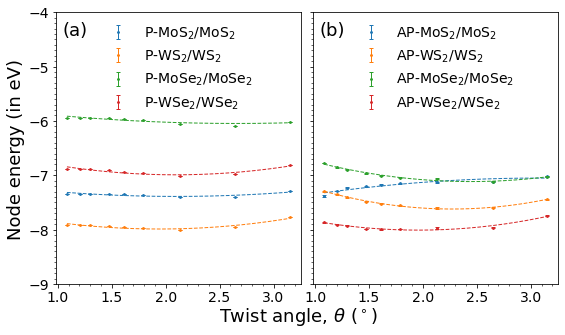

In [14]:
from matplotlib.ticker import MultipleLocator
fontsize = 14
plt.rcParams['font.size'] = fontsize
marker='H'

fig,axs = plt.subplots(1,2,figsize=(9,5))

for i,stacking in enumerate(['P','AP']):

    mpairs = [('Mo','Mo'),('W','W')]
    for x1 in ['S','Se']:
        for m1,m2 in mpairs:
            if m1==m2 or x1=='Se':
                iis= np.array([10,12,15,16,18,20,22,25,27,30,40])
            else:
                iis= np.array([10,12,15,16,18,20,22,25,27,30])
            iis = [10,12,15,18,20,22,25,27,30]

            label = rf'{stacking}-{m1}{x1}$_2$/{m2}{x1}$_2$'
            angles = [twist_angles[ii] for ii in iis]
            dict_data = node_energies_dict[f'{stacking}-{m1}{m2}{x1}']
            
            if m1==m2 and stacking=='P':
                means = dict_data
                stds = np.zeros(len(means))
            else:
                mask = dict_data != 0
                means = np.ma.masked_array(dict_data, mask=~mask).mean(axis=1)
                #print(means)
                #print(f'{label} : {means[np.where(iis==30)[0]]}')
                stds = np.ma.masked_array(dict_data, mask=~mask).std(axis=1)
    #             means = np.mean(dict_data,axis=1)
    #             stds = np.std(dict_data,axis=1)         
            #color = plt_colors[f'{m1}{x1}2/{m2}{x1}2']
            errorplot = axs[i].errorbar(angles,means,yerr=stds,fmt=marker,label=label,markersize=2,
                        elinewidth=1,capsize=2,capthick=1,barsabove=True)#,color=color)
            print(f'{stacking}-{m1}{x1}$_2$/{m2}{x1}$_2$ {means[0]} {np.mean(means)}')
            npoly=2

            poly = np.polyfit(angles,means,npoly)
            poly_angles = np.linspace(min(angles),max(angles),150)
            poly_means = np.polyval(poly,poly_angles)

            axs[i].plot(poly_angles,poly_means,color=errorplot[0].get_color(),linestyle='--',lw=1)

    axs[i].xaxis.set_minor_locator(MultipleLocator(0.1))
    axs[i].yaxis.set_minor_locator(MultipleLocator(0.1))
    axs[i].yaxis.set_major_locator(MultipleLocator(1))
    axs[i].set_ylim(-9,-4)
    axs[i].legend(frameon=False,fontsize=fontsize,loc='upper center')
    if i!=0:
        axs[i].tick_params(labelleft=False)
                
    axs[i].text(0.08,0.9,f"({chr(ord('a')+i)})",transform=axs[i].transAxes,
       ha='center',va='bottom',fontsize=fontsize+4)
            
fig.text(0.5, 0.02,r'Twist angle, $\theta\ (^\circ)$', ha='center', fontsize=fontsize+4)            
fig.text(0.05, 0.5,r"Node energy (in eV)", va='center',
         rotation='vertical',fontsize=fontsize+4)          
plt.subplots_adjust(wspace=0.05, hspace=0.1)
plt.savefig(f'node_energies.png',dpi=300,facecolor='white',transparent=False,
            bbox_inches='tight',pad_inches=0.02)

plt.show()

# Binding Energy as a function of twist angle

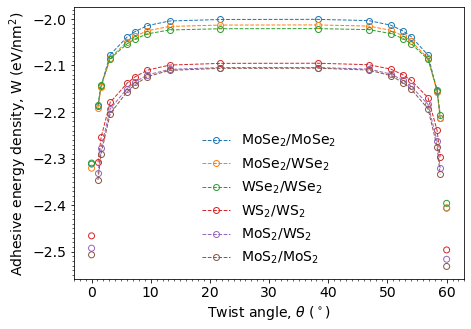

In [19]:
from matplotlib.ticker import MultipleLocator

fontsize = 14
plt.rcParams['font.size'] = fontsize
marker='H'

fig,axs = plt.subplots(1,1,figsize=(7,5))

iis = [1,2,3,4,5,10,20,30]
stackings = ['P','AP']

    
for x1 in ['Se','S']:
    
    if x1 == 'Se':
        mpairs = [('Mo','Mo'),('Mo','W'),('W','W')]
    else:
        mpairs = [('Mo','Mo'),('Mo','W'),('W','W')][::-1]
    
    for m1,m2 in mpairs:
        
        # Monolayer1 Energy
        mono1 = mx2(f'{m1}{x1}2',kind='2H',a=a_optb88[f'{m1}{x1}2'],thickness=t[f'{m1}{x1}2'],vacuum=8,size=(1,1,1))
        mono1.calc = calc
        dyn = BFGS(mono1)
        dyn.log = passlog
        dyn.run(fmax=0.001)
        mono1_energy = mono1.get_potential_energy()
        
        #Monolayer2 Energy
        mono2 = mx2(f'{m2}{x1}2',kind='2H',a=a_optb88[f'{m2}{x1}2'],thickness=t[f'{m2}{x1}2'],vacuum=8,size=(1,1,1))
        mono2.calc = calc
        dyn = BFGS(mono2)
        dyn.log = passlog
        dyn.run(fmax=0.001)
        mono2_energy = mono2.get_potential_energy()
        
        area = mono1.get_volume()/mono1.cell[2][2]
        
        #Binding energy MX' (0 degree)
        
        binding_energy_MX = 100*(energy_MX[f'{m1}{x1}2/{m2}{x1}2']-(mono1_energy+mono2_energy))/area
        
        #Binding energy 2H (60 degree)
        binding_energy_2H = 100*(energy_2H[f'{m1}{x1}2/{m2}{x1}2']-(mono1_energy+mono2_energy))/area
        
        angles = []
        binding_energies = []
        
        for stacking in stackings:
            
            if stacking == 'P':
                iis = [1,2,3,4,5,10,20,30][::-1]
            else:
                iis = [1,2,3,4,5,10,20,30]
                
            for ii in iis:
                
                if m1!=m2 and ii>10 and x1=='S':
                    xyzfile = f'../relaxations/relaxed_data/{m1}{x1}2_{m2}{x1}2_{stacking}_{ii}_twirl.xyz'
                else:
                    xyzfile = f'../relaxations/relaxed_data/{m1}{x1}2_{m2}{x1}2_{stacking}_{ii}.xyz'     
                atoms = read(xyzfile)
                nunitcells= len(atoms)//6
                area = atoms.get_volume()/atoms.cell[2][2]
                twist_angle = twist_angles[ii] if stacking=='P' else 60-twist_angles[ii]
                
                
                outfile = f'output_files/{m1}{x1}2_{m2}{x1}2_{stacking}_{ii}.out'
                relaxed_energy = read_lammps_energy(outfile)
                binding_energy = 100*(relaxed_energy - nunitcells*(mono1_energy+mono2_energy))/area
                angles.append(twist_angle)
                binding_energies.append(binding_energy)
        
        label = rf'{m1}{x1}$_2$/{m2}{x1}$_2$'
        line = axs.plot(angles,binding_energies,label=label,marker='o',lw=1,markerfacecolor='none',linestyle='--')
        axs.scatter([0,60],[binding_energy_MX,binding_energy_2H],color=line[0].get_color(),
                    facecolors='none')
#         axs.scatter(60,binding_energy_2H,color=line[0].get_color())
plt.legend(frameon=False)
axs.set_xlabel(r'Twist angle, $\theta\ (^\circ)$')
axs.set_ylabel('Adhesive energy density, W (eV/nm$^{2}$) ')                

axs.xaxis.set_minor_locator(MultipleLocator(1))
axs.yaxis.set_minor_locator(MultipleLocator(0.01))

plt.savefig(f'binding_e_vs_twist.png',dpi=300,facecolor='white',transparent=False,
            bbox_inches='tight',pad_inches=0.02)                
                
plt.show()